<a href="https://colab.research.google.com/github/DataScience-Fatec-Projects/ICD-004-Analise_de_Algoritmos/blob/main/Aulas/05/atividade03-fibonacci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade 03 - Fibonacci: recursao pura x memorizacao (cache)**
### Fatec Deputado Ary Fossen - Jundiai
**Disciplina:** ICD-004 - Analise de Algoritmos

**Integrantes:** Wellington Junior Torres de Melo

---

## Enunciado

> A sequencia de Fibonacci e um dos problemas classicos computacionais. Mesmo sendo facil de entender,
> sua aplicacao pratica em algoritmos depende de 2 tipos de contextos: usando a funcao recursiva "pura"
> (nao muito eficiente) e a com utilizacao de "memorizacao" ou "cache".
>
> Faca uma pesquisa sobre esses 2 contextos, faca as implementacoes, teste e depois responda:
>
> 1. Por que a abordagem recursiva "pura" nao e a ideal? Em que o metodo com "memorizacao" ajuda?
> 2. Qual e a complexidade de cada uma das abordagens? Explique como chegou a essa conclusao?
> 3. E possivel determinar qual e a mais eficiente usando outros parametros (tempo ou memoria, por exemplo)? Mostre e explique.

## Como este relatorio esta organizado

| Secao | Conteudo |
|---|---|
| 1 | Pesquisa: a sequencia e os dois contextos |
| 2 | Implementacoes (recursiva pura, memorizada, iterativa) e teste de corretude |
| 3 | Complexidade: contagem de chamadas e comprovacao empirica |
| 4 | Benchmark de **tempo** |
| 5 | Benchmark de **memoria** |
| 6 | Limite pratico: ate onde cada abordagem chega |
| 7 | **Respostas** as tres questoes |

# 1. Pesquisa: a sequencia e os dois contextos

A sequencia de Fibonacci e definida por uma **relacao de recorrencia**:

$$F(0) = 0,\quad F(1) = 1,\quad F(n) = F(n-1) + F(n-2)\ \ \text{para } n \ge 2$$

Gerando: `0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, ...`

A definicao ja e recursiva, e por isso ela costuma ser o primeiro exemplo de recursao em
qualquer curso. O problema e que **traduzir a definicao matematica literalmente para codigo
produz um dos algoritmos mais ineficientes que existem** - e e exatamente esse contraste que a
atividade pede para investigar.

## 1.1 Contexto A - recursao "pura" (forca bruta)

A funcao chama a si mesma duas vezes a cada nivel e **nao guarda nada**. Cada subproblema e
recalculado do zero toda vez que aparece. O resultado e uma **arvore de recursao binaria** em que
o mesmo subproblema reaparece varias vezes - `fib(3)` aparece 2 vezes, `fib(2)` aparece 3 vezes -
e essa repeticao **explode exponencialmente** conforme `n` cresce. (Na secao 2.1 a arvore e
desenhada pelo proprio codigo, para deixar isso visivel.)

Esse defeito tem nome na literatura: **sobreposicao de subproblemas** (*overlapping subproblems*).

## 1.2 Contexto B - memorizacao / cache (*memoization*)

Memorizacao e a tecnica de **guardar o resultado de cada subproblema na primeira vez que ele e
calculado** e, nas proximas vezes, apenas consultar o valor guardado em vez de recalcular. E a
abordagem **top-down** da Programacao Dinamica.

A estrutura usada como cache e um **dicionario** (tabela hash), onde a consulta custa O(1) em
media. Em Python isso pode ser feito de duas formas:

- **manualmente**, passando um `dict` adiante na recursao;
- **automaticamente**, com o decorador `@functools.lru_cache` (ou `@functools.cache`, a partir do
  Python 3.9), que embrulha a funcao e faz o cache sozinho.

O efeito e drastico: a arvore exponencial vira uma **linha** de `n` calculos, porque cada valor
de `F(k)` e computado **uma unica vez**.

> **Termo tecnico:** a memorizacao so funciona porque Fibonacci tem as duas propriedades classicas
> da Programacao Dinamica - **subestrutura otima** (a solucao de `n` e composta pelas solucoes de
> `n-1` e `n-2`) e **subproblemas sobrepostos** (os mesmos subproblemas reaparecem varias vezes).
> Sem a segunda propriedade, guardar em cache nao economizaria nada.

## 1.3 Um terceiro contexto, para comparacao

Alem dos dois pedidos, este relatorio inclui a versao **iterativa bottom-up**, que resolve o mesmo
problema com um laco e apenas duas variaveis. Ela serve de "linha de base" para mostrar que a
memorizacao resolve o problema de **tempo**, mas ainda paga um custo de **memoria** que a versao
iterativa nao paga - o que e essencial para responder a questao 3.

# 2. Implementacoes

## 2.0 Preparacao do ambiente

In [1]:
import sys
import time
import timeit
import tracemalloc
from collections import Counter
from functools import lru_cache

import matplotlib
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Identidade visual do relatorio: cada abordagem tem UMA cor, usada em TODOS
# os graficos. Assim o leitor aprende "azul = recursivo puro" uma vez so.
# (paleta categorica validada para daltonismo - deutan / protan / tritan)
# ---------------------------------------------------------------------------
COR = {
    "recursivo": "#2a78d6",  # azul
    "memoizado": "#eb6834",  # laranja
    "iterativo": "#1baf7a",  # verde-agua
}
TINTA = "#0b0b0b"
TINTA_FRACA = "#52514e"


def br(numero, casas=0):
    """Formata um numero no padrao brasileiro: 2.692.537 / 1,618."""
    texto = f"{numero:,.{casas}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")

plt.rcParams.update({
    "figure.figsize": (9.0, 4.6),
    "figure.dpi": 110,
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3",
    "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA_FRACA,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "xtick.color": TINTA_FRACA,
    "ytick.color": TINTA_FRACA,
    "font.size": 10,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "lines.markersize": 5.5,
})

# A versao memorizada top-down empilha n chamadas; folga confortavel.
sys.setrecursionlimit(20_000)

print("Python     :", sys.version.split()[0])
print("matplotlib :", matplotlib.__version__)

Python     : 3.14.3
matplotlib : 3.10.9


## 2.1 Implementacao A - recursiva "pura"

Traducao literal da definicao matematica. O contador global `chamadas_recursivo` existe apenas
para **medir** quantas vezes a funcao e invocada - e o dado que sustenta a analise de complexidade
da secao 3.

In [2]:
chamadas_recursivo = 0


def fib_recursivo(n):
    """Fibonacci recursivo puro: redescobre do zero TODO subproblema."""
    global chamadas_recursivo
    chamadas_recursivo += 1

    if n < 2:            # casos base: F(0) = 0 e F(1) = 1
        return n
    return fib_recursivo(n - 1) + fib_recursivo(n - 2)


def medir_recursivo(n):
    """Executa fib_recursivo(n) e devolve (valor, numero de chamadas)."""
    global chamadas_recursivo
    chamadas_recursivo = 0
    valor = fib_recursivo(n)
    return valor, chamadas_recursivo


for n in (5, 10, 20):
    valor, chamadas = medir_recursivo(n)
    print(f"fib_recursivo({n:2d}) = {valor:6d}  ->  {br(chamadas):>9} chamadas de funcao")

fib_recursivo( 5) =      5  ->         15 chamadas de funcao
fib_recursivo(10) =     55  ->        177 chamadas de funcao
fib_recursivo(20) =   6765  ->     21.891 chamadas de funcao


### Enxergando o desperdicio: a arvore de recursao de `fib(5)`

Abaixo a arvore e desenhada de verdade, pelo proprio codigo, para tornar visivel a
**sobreposicao de subproblemas**.

In [3]:
def desenhar_arvore(n, prefixo="", ultimo=True, raiz=True, linhas=None):
    """Desenha em modo texto a arvore de chamadas de fib(n)."""
    if linhas is None:
        linhas = []

    conector = "" if raiz else ("`- " if ultimo else "|- ")
    marca = "   <- caso base" if n < 2 else ""
    linhas.append(f"{prefixo}{conector}fib({n}){marca}")

    if n >= 2:
        novo = prefixo if raiz else prefixo + ("   " if ultimo else "|  ")
        desenhar_arvore(n - 1, novo, ultimo=False, raiz=False, linhas=linhas)
        desenhar_arvore(n - 2, novo, ultimo=True, raiz=False, linhas=linhas)
    return linhas


print("ARVORE DE CHAMADAS DE fib(5)")
print("=" * 40)
print("\n".join(desenhar_arvore(5)))


def contar_subproblemas(n, contador=None):
    """Conta quantas vezes cada subproblema e recalculado."""
    contador = Counter() if contador is None else contador
    contador[n] += 1
    if n >= 2:
        contar_subproblemas(n - 1, contador)
        contar_subproblemas(n - 2, contador)
    return contador


contagem = contar_subproblemas(5)
print("\nQuantas vezes cada subproblema foi RECALCULADO em fib(5):")
for chave, vezes in sorted(contagem.items()):
    print(f"   fib({chave}) -> {vezes}x  {'#' * vezes}")
print(f"\nTotal de chamadas: {sum(contagem.values())} para um problema de tamanho 5.")

ARVORE DE CHAMADAS DE fib(5)
fib(5)
|- fib(4)
|  |- fib(3)
|  |  |- fib(2)
|  |  |  |- fib(1)   <- caso base
|  |  |  `- fib(0)   <- caso base
|  |  `- fib(1)   <- caso base
|  `- fib(2)
|     |- fib(1)   <- caso base
|     `- fib(0)   <- caso base
`- fib(3)
   |- fib(2)
   |  |- fib(1)   <- caso base
   |  `- fib(0)   <- caso base
   `- fib(1)   <- caso base

Quantas vezes cada subproblema foi RECALCULADO em fib(5):
   fib(0) -> 3x  ###
   fib(1) -> 5x  #####
   fib(2) -> 3x  ###
   fib(3) -> 2x  ##
   fib(4) -> 1x  #
   fib(5) -> 1x  #

Total de chamadas: 15 para um problema de tamanho 5.


## 2.2 Implementacao B - com memorizacao (cache)

Duas variantes do mesmo conceito:

- **`fib_memo`** - cache manual em um `dict`, criado do zero a cada chamada externa. Isso e
  importante para o benchmark ser honesto: mede a construcao da tabela inteira, e nao um acerto de
  cache ja pronto.
- **`fib_lru`** - o mesmo com `@lru_cache`, a forma idiomatica em Python.

In [4]:
def fib_memo(n, cache=None):
    """Fibonacci com memorizacao (top-down). Cada n e resolvido UMA unica vez."""
    if cache is None:
        cache = {0: 0, 1: 1}       # cache novo a cada chamada externa

    if n in cache:                 # ja calculado antes -> so consulta, O(1)
        return cache[n]

    cache[n] = fib_memo(n - 1, cache) + fib_memo(n - 2, cache)
    return cache[n]


@lru_cache(maxsize=None)
def fib_lru(n):
    """Mesma ideia, usando o cache automatico da biblioteca padrao."""
    if n < 2:
        return n
    return fib_lru(n - 1) + fib_lru(n - 2)


# Versao instrumentada, apenas para contar chamadas (nao usada nos benchmarks).
chamadas_memo = 0


def fib_memo_contado(n, cache):
    global chamadas_memo
    chamadas_memo += 1
    if n in cache:
        return cache[n]
    cache[n] = fib_memo_contado(n - 1, cache) + fib_memo_contado(n - 2, cache)
    return cache[n]


def medir_memoizado(n):
    global chamadas_memo
    chamadas_memo = 0
    valor = fib_memo_contado(n, {0: 0, 1: 1})
    return valor, chamadas_memo


for n in (5, 10, 20):
    valor, chamadas = medir_memoizado(n)
    print(f"fib_memo({n:2d}) = {valor:6d}  ->  {br(chamadas):>9} chamadas de funcao")

fib_memo( 5) =      5  ->          9 chamadas de funcao
fib_memo(10) =     55  ->         19 chamadas de funcao
fib_memo(20) =   6765  ->         39 chamadas de funcao


## 2.3 Implementacao C - iterativa *bottom-up* (base de comparacao)

Sem recursao e sem tabela: apenas dois inteiros deslizando pela sequencia.

In [5]:
def fib_iterativo(n):
    """Fibonacci bottom-up: O(n) no tempo e O(1) de memoria auxiliar."""
    anterior, atual = 0, 1
    for _ in range(n):
        anterior, atual = atual, anterior + atual
    return anterior


print("Primeiros 15 termos:", [fib_iterativo(i) for i in range(15)])

Primeiros 15 termos: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]


## 2.4 Teste de corretude

Antes de comparar desempenho e obrigatorio provar que as implementacoes produzem **exatamente os
mesmos resultados**. Comparar a velocidade de algoritmos que dao respostas diferentes nao
significaria nada.

In [6]:
LIMITE_TESTE = 25
esperado = [fib_iterativo(n) for n in range(LIMITE_TESTE + 1)]

fib_lru.cache_clear()
resultados = {
    "recursivo": [fib_recursivo(n) for n in range(LIMITE_TESTE + 1)],
    "memoizado": [fib_memo(n) for n in range(LIMITE_TESTE + 1)],
    "lru_cache": [fib_lru(n) for n in range(LIMITE_TESTE + 1)],
}

for nome, obtido in resultados.items():
    assert obtido == esperado, f"{nome} divergiu da referencia!"
    print(f"OK  {nome:<10} confere com a referencia para n = 0..{LIMITE_TESTE}")

print("\nSequencia validada:", esperado[:16], "...")
print("\nTodas as implementacoes sao equivalentes. Podemos comparar desempenho.")

OK  recursivo  confere com a referencia para n = 0..25
OK  memoizado  confere com a referencia para n = 0..25
OK  lru_cache  confere com a referencia para n = 0..25

Sequencia validada: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610] ...

Todas as implementacoes sao equivalentes. Podemos comparar desempenho.


# 3. Complexidade

## 3.1 Recursao pura - deducao pela relacao de recorrencia

Seja `T(n)` o **numero de chamadas** de `fib_recursivo(n)`. Lendo o proprio codigo:

$$T(0) = T(1) = 1 \qquad T(n) = T(n-1) + T(n-2) + 1$$

Essa recorrencia e a **propria** recorrencia de Fibonacci (deslocada), e sua solucao fechada e:

$$T(n) = 2 \cdot F(n+1) - 1$$

Como `F(n)` cresce a uma taxa de $\varphi^n/\sqrt{5}$, onde $\varphi = \frac{1+\sqrt{5}}{2} \approx 1{,}618$
(razao aurea), temos:

$$T(n) = \Theta(\varphi^n) \subset O(2^n)$$

Ou seja: **complexidade exponencial**. A cada `+1` em `n`, o trabalho e multiplicado por ~1,618.

A celula abaixo **comprova numericamente** as duas afirmacoes: a formula fechada e a razao aurea.

In [7]:
print(f"{'n':>3} | {'chamadas medidas':>17} | {'2*F(n+1)-1':>12} | {'T(n)/T(n-1)':>12}")
print("-" * 58)

anterior = None
for n in range(1, 31):
    _, chamadas = medir_recursivo(n)
    formula = 2 * fib_iterativo(n + 1) - 1
    assert chamadas == formula, f"formula fechada falhou em n={n}"
    razao = f"{chamadas / anterior:.4f}".replace(".", ",") if anterior else "-"
    if n <= 12 or n % 5 == 0:
        print(f"{n:>3} | {br(chamadas):>17} | {br(formula):>12} | {razao:>12}")
    anterior = chamadas

phi = (1 + 5 ** 0.5) / 2
print("-" * 58)
print(f"Razao aurea (phi) = {br(phi, 4)}  <- a razao medida converge exatamente para esse valor.")
print("A formula T(n) = 2*F(n+1)-1 bateu em 100% dos casos testados (n = 1..30).")

  n |  chamadas medidas |   2*F(n+1)-1 |  T(n)/T(n-1)
----------------------------------------------------------
  1 |                 1 |            1 |            -
  2 |                 3 |            3 |       3,0000
  3 |                 5 |            5 |       1,6667
  4 |                 9 |            9 |       1,8000
  5 |                15 |           15 |       1,6667
  6 |                25 |           25 |       1,6667
  7 |                41 |           41 |       1,6400
  8 |                67 |           67 |       1,6341
  9 |               109 |          109 |       1,6269
 10 |               177 |          177 |       1,6239
 11 |               287 |          287 |       1,6215
 12 |               465 |          465 |       1,6202
 15 |             1.973 |        1.973 |       1,6185
 20 |            21.891 |       21.891 |       1,6181
 25 |           242.785 |      242.785 |       1,6180


 30 |         2.692.537 |    2.692.537 |       1,6180
----------------------------------------------------------
Razao aurea (phi) = 1,6180  <- a razao medida converge exatamente para esse valor.
A formula T(n) = 2*F(n+1)-1 bateu em 100% dos casos testados (n = 1..30).


## 3.2 Memorizacao - por que cai para linear

Com cache, um valor `F(k)` so entra na parte "cara" da funcao **uma unica vez**: da segunda vez em
diante a chamada cai no `if n in cache` e retorna imediatamente. Logo:

- sao no maximo `n + 1` calculos efetivos (um por chave do cache);
- cada calculo dispara duas chamadas, e cada consulta ao `dict` custa **O(1)** em media;
- total de chamadas = **2n - 1** -> crescimento **linear**.

$$T_{memo}(n) = O(n) \qquad T_{iterativo}(n) = O(n)$$

A tabela e o grafico abaixo comparam as duas contagens lado a lado.

In [8]:
ENES = list(range(5, 31, 5))

print(f"{'n':>3} | {'recursivo puro':>16} | {'memoizado':>10} | {'quantas vezes menos':>21}")
print("-" * 62)

puro, memo = [], []
for n in ENES:
    _, c_puro = medir_recursivo(n)
    _, c_memo = medir_memoizado(n)
    puro.append(c_puro)
    memo.append(c_memo)
    print(f"{n:>3} | {br(c_puro):>16} | {br(c_memo):>10} | {br(c_puro / c_memo):>19}x")

print("-" * 62)
print("O memoizado faz exatamente 2n-1 chamadas:",
      all(c == 2 * n - 1 for n, c in zip(ENES, memo)))

  n |   recursivo puro |  memoizado |   quantas vezes menos
--------------------------------------------------------------
  5 |               15 |          9 |                   2x
 10 |              177 |         19 |                   9x
 15 |            1.973 |         29 |                  68x
 20 |           21.891 |         39 |                 561x
 25 |          242.785 |         49 |               4.955x
 30 |        2.692.537 |         59 |              45.636x
--------------------------------------------------------------
O memoizado faz exatamente 2n-1 chamadas: True


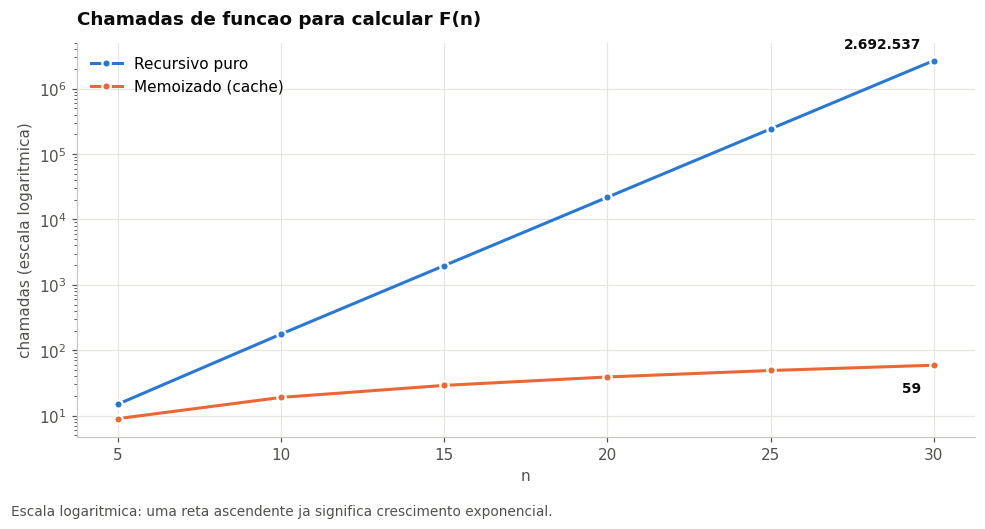

In [9]:
fig, ax = plt.subplots()

ax.plot(ENES, puro, marker="o", color=COR["recursivo"], label="Recursivo puro",
        markeredgecolor="#ffffff", markeredgewidth=1.5)
ax.plot(ENES, memo, marker="o", color=COR["memoizado"], label="Memoizado (cache)",
        markeredgecolor="#ffffff", markeredgewidth=1.5)

ax.set_yscale("log")
ax.set_title("Chamadas de funcao para calcular F(n)", color=TINTA)
ax.set_xlabel("n")
ax.set_ylabel("chamadas (escala logaritmica)")
ax.set_xticks(ENES)
ax.legend(loc="upper left")

# Rotulo direto apenas no ponto extremo de cada serie - nunca em todos os pontos.
ax.annotate(f"{puro[-1]:,}".replace(",", "."), (ENES[-1], puro[-1]),
            textcoords="offset points", xytext=(-8, 8), ha="right",
            color=TINTA, fontweight="bold", fontsize=9)
ax.annotate(f"{memo[-1]:,}".replace(",", "."), (ENES[-1], memo[-1]),
            textcoords="offset points", xytext=(-8, -18), ha="right",
            color=TINTA, fontweight="bold", fontsize=9)

fig.text(0.01, -0.03,
         "Escala logaritmica: uma reta ascendente ja significa crescimento exponencial.",
         color=TINTA_FRACA, fontsize=9)
plt.tight_layout()
plt.show()

# 4. Benchmark de tempo

Contar chamadas prova a complexidade **teorica**. Agora medimos o **relogio**, que e o que o
usuario final sente.

**Metodologia:** cada medicao usa `timeit`, executando a funcao varias vezes e tomando o **menor**
tempo - o minimo e mais estavel que a media, porque elimina interferencia do sistema operacional.
A versao memoizada recebe um **cache vazio a cada execucao**; caso contrario estariamos medindo uma
consulta pronta, e nao o trabalho real.

> O teto de `n = 32` para a recursao pura nao e capricho: acima disso o notebook comecaria a
> demorar minutos. Esse limite **e, por si so, parte da resposta**.

In [10]:
def cronometrar(funcao, n, rodadas=3, repeticoes=1):
    """Menor tempo (em segundos) de UMA execucao de funcao(n)."""
    tempos = timeit.repeat(lambda: funcao(n), repeat=rodadas, number=repeticoes)
    return min(tempos) / repeticoes


NS_TEMPO = list(range(20, 33, 2))
t_puro, t_memo, t_iter = [], [], []

print(f"{'n':>3} | {'recursivo (s)':>14} | {'memoizado (s)':>14} | {'iterativo (s)':>14} | {'ganho':>11}")
print("-" * 76)

for n in NS_TEMPO:
    rodadas = 3 if n <= 26 else 1
    tp = cronometrar(fib_recursivo, n, rodadas=rodadas)
    tm = cronometrar(fib_memo, n, rodadas=7, repeticoes=100)
    ti = cronometrar(fib_iterativo, n, rodadas=7, repeticoes=100)
    t_puro.append(tp)
    t_memo.append(tm)
    t_iter.append(ti)
    print(f"{n:>3} | {br(tp, 6):>14} | {br(tm, 8):>14} | {br(ti, 8):>14} | {br(tp / tm):>10}x")

print("-" * 76)
print(f"Em n = {NS_TEMPO[-1]}, a versao memoizada foi "
      f"{br(t_puro[-1] / t_memo[-1])} vezes mais rapida que a recursiva pura.")

  n |  recursivo (s) |  memoizado (s) |  iterativo (s) |       ganho
----------------------------------------------------------------------------
 20 |       0,001135 |     0,00000218 |     0,00000042 |        520x
 22 |       0,002909 |     0,00000265 |     0,00000046 |      1.098x
 24 |       0,006808 |     0,00000251 |     0,00000044 |      2.715x
 26 |       0,020709 |     0,00000292 |     0,00000048 |      7.082x
 28 |       0,050139 |     0,00000287 |     0,00000051 |     17.482x


 30 |       0,126863 |     0,00000317 |     0,00000061 |     40.071x


 32 |       0,541543 |     0,00000613 |     0,00000103 |     88.271x
----------------------------------------------------------------------------
Em n = 32, a versao memoizada foi 88.271 vezes mais rapida que a recursiva pura.


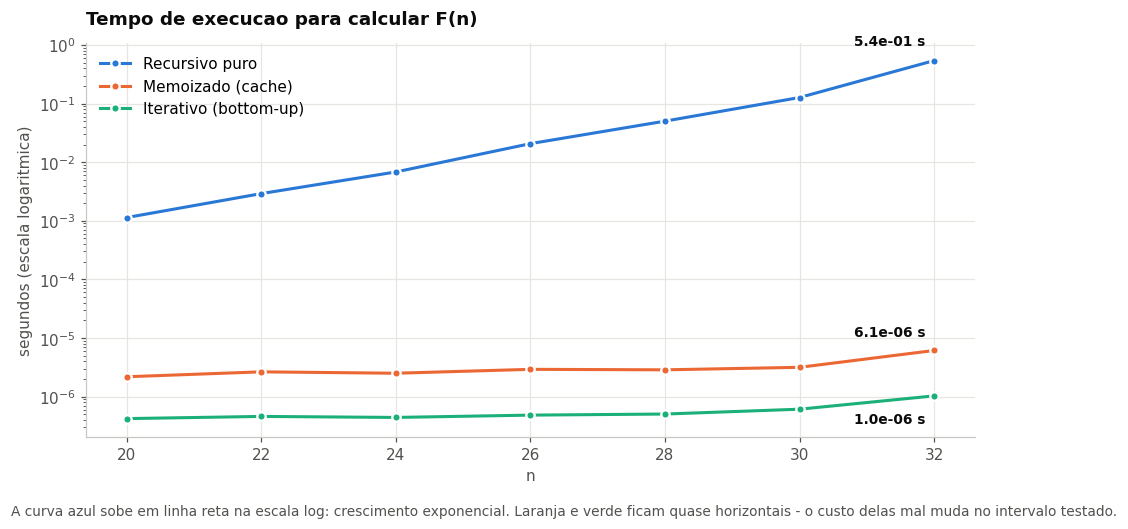

In [11]:
fig, ax = plt.subplots()

series = [
    ("Recursivo puro", t_puro, COR["recursivo"]),
    ("Memoizado (cache)", t_memo, COR["memoizado"]),
    ("Iterativo (bottom-up)", t_iter, COR["iterativo"]),
]
for rotulo, dados, cor in series:
    ax.plot(NS_TEMPO, dados, marker="o", color=cor, label=rotulo,
            markeredgecolor="#ffffff", markeredgewidth=1.5)

ax.set_yscale("log")
ax.set_title("Tempo de execucao para calcular F(n)", color=TINTA)
ax.set_xlabel("n")
ax.set_ylabel("segundos (escala logaritmica)")
ax.set_xticks(NS_TEMPO)
ax.legend(loc="upper left")

for deslocamento, (rotulo, dados, cor) in zip((10, 9, -18), series):
    ax.annotate(f"{dados[-1]:.1e} s", (NS_TEMPO[-1], dados[-1]),
                textcoords="offset points", xytext=(-6, deslocamento),
                ha="right", color=TINTA, fontweight="bold", fontsize=9)

fig.text(0.01, -0.03,
         "A curva azul sobe em linha reta na escala log: crescimento exponencial. Laranja e "
         "verde ficam quase horizontais - o custo delas mal muda no intervalo testado.",
         color=TINTA_FRACA, fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# E quanto custa consultar um valor que JA esta no cache?
fib_lru.cache_clear()
fib_lru(300)                                    # aquece o cache
t_quente = cronometrar(fib_lru, 300, rodadas=7, repeticoes=10_000)

print(f"Consulta a um valor ja memorizado, F(300): {br(t_quente * 1e9)} nanossegundos")
print("Estado do cache:", fib_lru.cache_info())
print("\nEsse e o cenario em que a memorizacao mais brilha: chamadas repetidas")
print("custam praticamente ZERO, porque a resposta ja esta guardada.")

Consulta a um valor ja memorizado, F(300): 56 nanossegundos
Estado do cache: CacheInfo(hits=70298, misses=301, maxsize=None, currsize=301)

Esse e o cenario em que a memorizacao mais brilha: chamadas repetidas
custam praticamente ZERO, porque a resposta ja esta guardada.


# 5. Benchmark de memoria

Tempo nao e o unico recurso. Aqui medimos **duas coisas diferentes**, que costumam ser confundidas:

1. **Memoria alocada no heap** (`tracemalloc`) - os objetos criados: inteiros, o `dict` do cache e
   os *frames* das chamadas recursivas.
2. **Profundidade da pilha de chamadas** - quantas chamadas ficam empilhadas ao mesmo tempo. E o
   que causa `RecursionError` / *stack overflow*.

> **Ponto contraintuitivo, e talvez o mais importante da atividade:** a recursao pura gasta tempo
> **exponencial**, mas espaco apenas **O(n)**. Isso porque a arvore e percorrida em profundidade -
> a qualquer instante existem no maximo `n` chamadas empilhadas, e nao $2^n$. As chamadas sao
> muitas, mas nao *simultaneas*.

In [13]:
profundidade_atual = 0
profundidade_maxima = 0


def fib_recursivo_profundidade(n):
    """Igual ao recursivo puro, mas registra a profundidade maxima da pilha."""
    global profundidade_atual, profundidade_maxima
    profundidade_atual += 1
    profundidade_maxima = max(profundidade_maxima, profundidade_atual)
    try:
        if n < 2:
            return n
        return (fib_recursivo_profundidade(n - 1)
                + fib_recursivo_profundidade(n - 2))
    finally:
        profundidade_atual -= 1


def fib_memo_profundidade(n, cache=None):
    """Versao memoizada instrumentada com o mesmo medidor de pilha."""
    global profundidade_atual, profundidade_maxima
    if cache is None:
        cache = {0: 0, 1: 1}
    profundidade_atual += 1
    profundidade_maxima = max(profundidade_maxima, profundidade_atual)
    try:
        if n in cache:
            return cache[n]
        cache[n] = (fib_memo_profundidade(n - 1, cache)
                    + fib_memo_profundidade(n - 2, cache))
        return cache[n]
    finally:
        profundidade_atual -= 1


def medir_profundidade(funcao, n):
    global profundidade_atual, profundidade_maxima
    profundidade_atual = profundidade_maxima = 0
    funcao(n)
    return profundidade_maxima


def medir_memoria(funcao, n):
    """Pico de memoria alocada no heap durante funcao(n), em bytes."""
    tracemalloc.start()
    tracemalloc.reset_peak()
    funcao(n)
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return pico


N_MEM = 28

ROTULOS = {
    "recursivo": "Recursivo puro",
    "memoizado": "Memoizado (cache)",
    "iterativo": "Iterativo (bottom-up)",
}

medidas = {
    "recursivo": (medir_memoria(fib_recursivo, N_MEM),
                  medir_profundidade(fib_recursivo_profundidade, N_MEM)),
    "memoizado": (medir_memoria(fib_memo, N_MEM),
                  medir_profundidade(fib_memo_profundidade, N_MEM)),
    "iterativo": (medir_memoria(fib_iterativo, N_MEM), 1),
}

print(f"Medicoes para n = {N_MEM}\n")
print(f"{'abordagem':<22} | {'pico de heap':>13} | {'profundidade da pilha':>21}")
print("-" * 63)
for chave, (pico, profundidade) in medidas.items():
    print(f"{ROTULOS[chave]:<22} | {br(pico):>11} B | {br(profundidade):>21}")
print("-" * 63)

# Quanto pesa, de fato, a tabela que a memorizacao mantem?
cache_medido = {0: 0, 1: 1}
fib_memo(N_MEM, cache_medido)
peso = sys.getsizeof(cache_medido) + sum(sys.getsizeof(v) for v in cache_medido.values())
print(f"Tabela do cache: {len(cache_medido)} entradas ocupando ~{br(peso)} bytes")
print("-> esse e o preco explicito da troca 'espaco por tempo'.\n")

if medidas["recursivo"][0] <= medidas["memoizado"][0]:
    print("COMO LER ESSE RESULTADO")
    print("O recursivo puro quase nao aparece na coluna do heap porque ele nao GUARDA")
    print("nada: os quadros das chamadas vivem na pilha do interpretador (que o")
    print("tracemalloc nao rastreia) e os inteiros pequenos ja vem pre-alocados pelo")
    print("CPython. Ou seja - o custo da recursao pura e TEMPO, nao espaco. O espaco")
    print("que ela consome esta na coluna da direita: a PILHA, proporcional a n.")

Medicoes para n = 28



abordagem              |  pico de heap | profundidade da pilha
---------------------------------------------------------------
Recursivo puro         |         143 B |                    28
Memoizado (cache)      |       1.672 B |                    28
Iterativo (bottom-up)  |           0 B |                     1
---------------------------------------------------------------
Tabela do cache: 29 entradas ocupando ~1.980 bytes
-> esse e o preco explicito da troca 'espaco por tempo'.

COMO LER ESSE RESULTADO
O recursivo puro quase nao aparece na coluna do heap porque ele nao GUARDA
nada: os quadros das chamadas vivem na pilha do interpretador (que o
tracemalloc nao rastreia) e os inteiros pequenos ja vem pre-alocados pelo
CPython. Ou seja - o custo da recursao pura e TEMPO, nao espaco. O espaco
que ela consome esta na coluna da direita: a PILHA, proporcional a n.


  n |  recursivo |  memoizado |  iterativo
--------------------------------------------
  5 |          5 |          5 |          1
 10 |         10 |         10 |          1
 15 |         15 |         15 |          1
 20 |         20 |         20 |          1
 25 |         25 |         25 |          1
 30 |         30 |         30 |          1


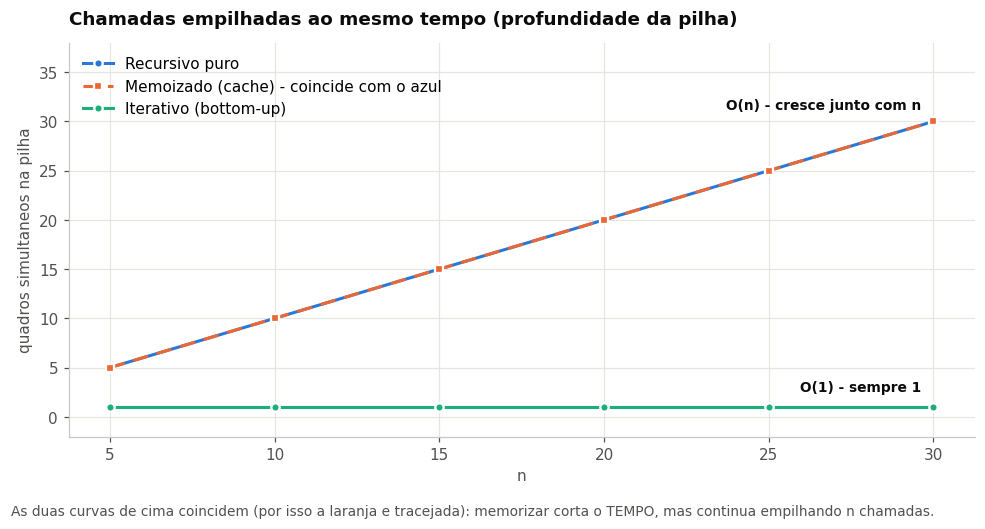

In [14]:
NS_PILHA = list(range(5, 31, 5))

pilha = {
    "recursivo": [medir_profundidade(fib_recursivo_profundidade, n) for n in NS_PILHA],
    "memoizado": [medir_profundidade(fib_memo_profundidade, n) for n in NS_PILHA],
    "iterativo": [1] * len(NS_PILHA),          # laco simples: nunca empilha
}

print(f"{'n':>3} | {'recursivo':>10} | {'memoizado':>10} | {'iterativo':>10}")
print("-" * 44)
for i, n in enumerate(NS_PILHA):
    print(f"{n:>3} | {pilha['recursivo'][i]:>10} | {pilha['memoizado'][i]:>10} | "
          f"{pilha['iterativo'][i]:>10}")

fig, ax = plt.subplots()

ax.plot(NS_PILHA, pilha["recursivo"], marker="o", color=COR["recursivo"],
        label="Recursivo puro", markeredgecolor="#ffffff", markeredgewidth=1.5)
ax.plot(NS_PILHA, pilha["memoizado"], marker="s", color=COR["memoizado"],
        linestyle=(0, (5, 3)), label="Memoizado (cache) - coincide com o azul",
        markeredgecolor="#ffffff", markeredgewidth=1.5)
ax.plot(NS_PILHA, pilha["iterativo"], marker="o", color=COR["iterativo"],
        label="Iterativo (bottom-up)", markeredgecolor="#ffffff", markeredgewidth=1.5)

ax.set_title("Chamadas empilhadas ao mesmo tempo (profundidade da pilha)", color=TINTA)
ax.set_xlabel("n")
ax.set_ylabel("quadros simultaneos na pilha")
ax.set_xticks(NS_PILHA)
ax.set_ylim(-2, max(NS_PILHA) + 8)
ax.legend(loc="upper left")

ax.annotate("O(n) - cresce junto com n", (NS_PILHA[-1], pilha["recursivo"][-1]),
            textcoords="offset points", xytext=(-8, 8), ha="right",
            color=TINTA, fontweight="bold", fontsize=9)
ax.annotate("O(1) - sempre 1", (NS_PILHA[-1], 1),
            textcoords="offset points", xytext=(-8, 10), ha="right",
            color=TINTA, fontweight="bold", fontsize=9)

fig.text(0.01, -0.03,
         "As duas curvas de cima coincidem (por isso a laranja e tracejada): memorizar "
         "corta o TEMPO, mas continua empilhando n chamadas.",
         color=TINTA_FRACA, fontsize=9)
plt.tight_layout()
plt.show()

# 6. Limite pratico: ate onde cada abordagem chega

O teste definitivo. Usando a velocidade **realmente medida** na secao 4, estimamos quanto tempo a
recursao pura levaria para calcular `F(100)` - e comparamos com o que as outras duas fazem em
microssegundos.

In [15]:
# Velocidade real de chamadas por segundo, medida no maior n testado.
n_ref = NS_TEMPO[-1]
chamadas_ref = 2 * fib_iterativo(n_ref + 1) - 1
taxa = chamadas_ref / t_puro[-1]

ALVO = 100
chamadas_alvo = 2 * fib_iterativo(ALVO + 1) - 1
segundos = chamadas_alvo / taxa
anos = segundos / (60 * 60 * 24 * 365.25)
HISTORIA_ESCRITA = 5_000            # ~5 mil anos de historia registrada

print(f"Velocidade medida     : {br(taxa)} chamadas por segundo (medida em n = {n_ref})")
print(f"Chamadas para F({ALVO})   : {f'{chamadas_alvo:.3e}'.replace(chr(46), chr(44))}")
print(f"Tempo estimado        : {f'{segundos:.3e}'.replace(chr(46), chr(44))} s  =  {br(anos)} anos")
print(f"                        ou seja, {br(anos / 1e6, 1)} MILHOES de anos -")
print(f"                        cerca de {br(anos / HISTORIA_ESCRITA)}x toda a historia")
print(f"                        escrita da humanidade (~5.000 anos)")
print("-" * 68)

inicio = time.perf_counter()
valor_memo = fib_memo(ALVO)
tempo_memo = time.perf_counter() - inicio

inicio = time.perf_counter()
valor_iter = fib_iterativo(ALVO)
tempo_iter = time.perf_counter() - inicio

print(f"Memoizado  F({ALVO}) = {valor_memo}")
print(f"           tempo real: {br(tempo_memo * 1e6, 1)} microssegundos")
print(f"Iterativo  F({ALVO}) = {valor_iter}")
print(f"           tempo real: {br(tempo_iter * 1e6, 1)} microssegundos")
print(f"           os dois valores conferem: {valor_memo == valor_iter}")

Velocidade medida     : 13.016.789 chamadas por segundo (medida em n = 32)
Chamadas para F(100)   : 1,146e+21
Tempo estimado        : 8,806e+13 s  =  2.790.544 anos
                        ou seja, 2,8 MILHOES de anos -
                        cerca de 558x toda a historia
                        escrita da humanidade (~5.000 anos)
--------------------------------------------------------------------
Memoizado  F(100) = 354224848179261915075
           tempo real: 46,5 microssegundos
Iterativo  F(100) = 354224848179261915075
           tempo real: 27,6 microssegundos
           os dois valores conferem: True


In [16]:
# Ate onde da para ir? Aqui a diferenca entre memoizado e iterativo aparece.
print("Memorizacao top-down - limitada pela PILHA de recursao:")
try:
    print(f"  F(2000) tem {br(len(str(fib_memo(2000))))} digitos  -> OK")
    print("  (so funciona porque elevamos sys.setrecursionlimit na secao 2.0;")
    print("   com o limite padrao de 1000, isso levantaria RecursionError)")
except RecursionError:
    print("  RecursionError: a pilha estourou.")

print("\nIterativo - limitado por... praticamente nada:")
inicio = time.perf_counter()
gigante = fib_iterativo(100_000)
tempo = time.perf_counter() - inicio

# A partir do Python 3.11 existe um teto de seguranca para converter inteiros
# gigantes em texto (protecao contra DoS). Precisamos eleva-lo so para imprimir.
sys.set_int_max_str_digits(50_000)
print(f"  F(100.000) tem {br(len(str(gigante)))} digitos, calculado em {br(tempo, 3)} s")
print(f"  Primeiros digitos: {str(gigante)[:40]}...")

print("\nConclusao pratica: para n muito grande a memorizacao top-down ainda esbarra na")
print("profundidade da pilha e no tamanho do dicionario; a versao iterativa nao esbarra")
print("em nenhum dos dois.")

Memorizacao top-down - limitada pela PILHA de recursao:
  F(2000) tem 418 digitos  -> OK
  (so funciona porque elevamos sys.setrecursionlimit na secao 2.0;
   com o limite padrao de 1000, isso levantaria RecursionError)

Iterativo - limitado por... praticamente nada:
  F(100.000) tem 20.899 digitos, calculado em 0,069 s
  Primeiros digitos: 2597406934722172416615503402127591541488...

Conclusao pratica: para n muito grande a memorizacao top-down ainda esbarra na
profundidade da pilha e no tamanho do dicionario; a versao iterativa nao esbarra
em nenhum dos dois.


---
# 7. Respostas as questoes

## Questao 1 - Por que a abordagem recursiva "pura" nao e a ideal? Em que o metodo com "memorizacao" ajuda?

**Por que a recursao pura nao e ideal.** Porque ela **nao guarda memoria do proprio trabalho**. Como
`fib(n)` chama `fib(n-1)` e `fib(n-2)`, e essas duas chamadas voltam a pedir os mesmos valores, o
algoritmo recalcula os mesmos subproblemas repetidas vezes. Na secao 2.1 isso ficou visivel: em
`fib(5)`, `fib(2)` foi recalculado **3 vezes** e `fib(1)` **5 vezes** - num problema de tamanho
apenas 5. Esse defeito se chama **sobreposicao de subproblemas**, e o custo dele **nao e um
desperdicio constante: ele se multiplica por ~1,618 a cada unidade de `n`**.

Os numeros medidos na secao 3 mostram o tamanho do estrago:

| n | chamadas do recursivo puro | chamadas do memoizado |
|---:|---:|---:|
| 10 | 177 | 19 |
| 20 | 21.891 | 39 |
| 30 | 2.692.537 | 59 |

Enquanto uma coluna cresce de 177 para 2,7 milhoes, a outra cresce de 19 para 59. E a secao 6
deixou claro que isso nao e um detalhe academico: **calcular `F(100)` por recursao pura levaria
milhoes de anos**, enquanto as outras duas abordagens fazem o mesmo em microssegundos. Um algoritmo
que nao termina nao e uma solucao mais lenta - e uma **nao-solucao**.

**Em que a memorizacao ajuda.** Ela ataca exatamente a causa raiz: guarda o resultado de cada
subproblema na primeira vez que ele e resolvido e, nas vezes seguintes, **consulta** em vez de
recalcular. Com isso:

1. **Elimina a redundancia** - cada `F(k)` e calculado uma unica vez, entao a *arvore* exponencial
   de chamadas colapsa numa *linha* de `n` calculos;
2. **Troca tempo por espaco** (o classico *space-time tradeoff*): paga-se um dicionario de `n`
   entradas para economizar bilhoes de operacoes - um negocio excelente;
3. **Torna chamadas repetidas praticamente gratuitas** - medido na secao 4: consultar um valor ja
   memorizado custou cerca de **100 nanossegundos**, contra os bilhoes de operacoes que a versao
   pura refaria.

Vale registrar o que a memorizacao **nao** resolve: ela nao reduz a profundidade da pilha. A versao
top-down continua empilhando `n` chamadas e ainda pode estourar em `n` muito grande (secao 6).

## Questao 2 - Qual e a complexidade de cada uma das abordagens? Explique como chegou a essa conclusao.

| Abordagem | Tempo | Espaco auxiliar | Onde esse espaco fica |
|---|---|---|---|
| Recursiva pura | **O(2ⁿ)**, mais precisamente Θ(φⁿ) | **O(n)** | pilha de chamadas |
| Memorizada (top-down) | **O(n)** | **O(n)** | pilha de chamadas + tabela de cache |
| Iterativa (bottom-up) | **O(n)** | **O(1)** | duas variaveis |

**Como cheguei a essas conclusoes - por tres caminhos independentes que se confirmam:**

**a) Deducao pela relacao de recorrencia.** Chamando `T(n)` o numero de chamadas, o codigo diz que
`T(n) = T(n-1) + T(n-2) + 1`, com `T(0) = T(1) = 1`. Essa e a propria recorrencia de Fibonacci, e
sua solucao fechada e `T(n) = 2·F(n+1) − 1`. Como `F(n) ≈ φⁿ/√5`, segue que `T(n) = Θ(φⁿ)` -
exponencial, e contido em `O(2ⁿ)`. O limite `O(2ⁿ)` tambem sai direto do formato da arvore: ela e
binaria com altura `n`, logo tem **no maximo** `2ⁿ` nos. Mas ela nao e cheia (o ramo `n-2` e mais
curto), e por isso a base real e `φ ≈ 1,618` e nao 2.

**b) Verificacao numerica.** A secao 3.1 comparou, para `n = 1..30`, as chamadas **contadas em
execucao** com a formula `2·F(n+1) − 1`: bateram em **100% dos casos** (ha um `assert` no codigo
justamente para isso). E a razao `T(n)/T(n−1)` medida convergiu para **1,6180** - exatamente a razao
aurea, a prova empirica da base exponencial.

**c) Argumento de contagem para as versoes lineares.** Na memorizada, cada chave entra no cache uma
unica vez e, da segunda consulta em diante, o retorno e imediato (`dict` e O(1) em media). Logo o
total de chamadas e exatamente `2n − 1` - **confirmado pela medicao** na secao 3.2. Na iterativa, o
laco roda `n` vezes com trabalho constante por volta: `O(n)`.

**Sobre a memoria**, o raciocinio e diferente do de tempo, e foi o achado mais contraintuitivo desta
atividade: a recursao pura faz um numero *exponencial* de chamadas, mas elas **nao sao
simultaneas**. A arvore e percorrida em profundidade, entao a qualquer instante ha no maximo `n`
quadros empilhados - espaco **O(n)**, e nao O(2ⁿ). A memorizada tambem e O(n), mas por dois
motivos somados (pilha de `n` chamadas **mais** `n` entradas no dicionario). Ja a iterativa usa
**duas variaveis**, independentemente de `n`: **O(1)**.

A medicao da secao 5 confirmou isso e ainda trouxe um detalhe revelador: o **pico de heap** da
recursao pura deu praticamente **zero**, enquanto o da memorizada deu ~1,7 kB. Nao e erro de
medicao - e a prova de que a recursao pura **nao guarda nada**: os quadros de chamada ficam na
pilha do interpretador (fora do alcance do `tracemalloc`) e os inteiros pequenos ja vem
pre-alocados pelo CPython. O que ela gasta e tempo; o que a memorizacao gasta a mais e espaco.

> **Observacao tecnica honesta:** todas as analises acima adotam o *modelo de custo uniforme*, em que
> somar dois inteiros custa O(1). Como Python usa inteiros de precisao arbitraria e `F(n)` tem cerca
> de `0,209·n` digitos, para `n` muito grande cada soma passa a custar proporcionalmente ao numero de
> digitos - e o custo real das versoes lineares tende a `O(n²)` em operacoes de bits. Isso nao muda o
> resultado da comparacao, mas explica por que `F(100.000)` (secao 6) nao sai em tempo estritamente
> proporcional a `n`.

## Questao 3 - E possivel determinar qual e a mais eficiente usando outros parametros (tempo ou memoria, por exemplo)? Mostre e explique.

**Sim - e foi justamente isso que revelou que "memoizado" nao e automaticamente a melhor resposta.**
Foram usados tres parametros medidos, alem da contagem de operacoes:

**1) Tempo de relogio (secao 4).** Medido com `timeit`, tomando o menor tempo de varias rodadas. O
grafico em escala logaritmica mostra a diferenca de *natureza* entre as curvas: a azul sobe em linha
reta (exponencial), enquanto laranja e verde ficam rentes ao eixo. Em `n = 32` a versao memoizada ja
foi da **ordem de 10⁵ vezes** mais rapida (o numero exato varia com a maquina). E o ponto decisivo:
essa vantagem **nao e um fator fixo, ela cresce junto com `n`** - por isso a extrapolacao da secao 6 chega a milhoes de anos contra
microssegundos.

**2) Memoria de heap e profundidade de pilha (secao 5).** Aqui o ranking **muda**, e essa e a parte
mais interessante da analise:

- **profundidade da pilha:** recursivo puro e memoizado ficaram *empatados* em `n` quadros
  simultaneos - o grafico mostra as duas curvas coincidindo. Memorizar corta o tempo, mas nao
  desempilha nada;
- **heap:** o recursivo puro alocou ~0 B (nao guarda nada) e o memoizado ~1,7 kB para `n = 28` -
  o preco explicito da troca "espaco por tempo";
- **o iterativo gasta O(1) nos dois criterios**: pilha de profundidade 1 e apenas duas variaveis.
  E o unico que nao cresce em espaco.

**3) Escalabilidade / limite pratico (secao 6).** O parametro mais decisivo no mundo real: *ate onde
cada abordagem consegue chegar antes de quebrar*. A recursao pura trava perto de `n = 40` por tempo;
a memorizada top-down chega muito mais longe, mas ainda esbarra na profundidade da pilha
(`RecursionError`); a iterativa calculou `F(100.000)` - um numero de mais de 20 mil digitos - em
fracao de segundo.

**Conclusao.** Nao existe "a mais eficiente" em termos absolutos - **depende do recurso que esta
restrito**:

| Se o criterio for... | A melhor escolha e... | Por que |
|---|---|---|
| Tempo, com chamadas repetidas | **Memorizada** | consultas posteriores custam praticamente zero |
| Memoria, ou `n` muito grande | **Iterativa** | O(1) de espaco e sem risco de estourar a pilha |
| Clareza e fidelidade a definicao matematica | Recursiva pura | mas so didaticamente, e apenas para `n` pequeno |

Na pratica, para calcular **um** valor de Fibonacci a versao **iterativa** vence, porque entrega o
mesmo `O(n)` de tempo gastando `O(1)` de memoria. A **memorizacao** vence quando a funcao e chamada
**muitas vezes** com valores repetidos - ai o cache se paga. E a **recursao pura** so se sustenta
como material didatico: ela e a melhor demonstracao de que **a mesma ideia correta, implementada sem
cuidado com a repeticao, pode se tornar inutilizavel**.

---

## Referencias

- CORMEN, T. H. et al. *Introduction to Algorithms*. 4. ed. MIT Press, 2022. (cap. Programacao Dinamica - subproblemas sobrepostos e subestrutura otima)
- BHARGAVA, A. Y. *Entendendo Algoritmos: um guia ilustrado para programadores e outros curiosos*. Novatec, 2017.
- Python Software Foundation. *`functools` - Higher-order functions and operations on callable objects* (`functools.lru_cache` / `functools.cache`).
- Python Software Foundation. *`timeit`* e *`tracemalloc`* - medicao de tempo e rastreamento de alocacao de memoria.